# Entendiendo las Convoluciones en Deep Learning

¡Hola! Ahora que ya sabemos manipular imágenes como tensores y entendemos la relación de los canales RGB, vamos a dar el siguiente paso: **Las Convoluciones**.

Una convolución es una operación matemática fundamental en las Redes Neuronales Convolucionales (CNNs). En lugar de mirar toda la imagen a la vez (como lo haría una capa densa o lineal), una convolución mira **pequeños parches** de la imagen para encontrar patrones locales: como bordes, esquinas, texturas y colores.

En resumen, una convolución aplica un pequeño filtro (o *kernel*) que se desliza por toda la imagen.

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Configuración para que PyTorch imprima números redondeados
torch.set_printoptions(sci_mode=False, precision=4)

### 1. Cargando una imagen de prueba
Vamos a cargar una imagen desde una URL para poder aplicar nuestros filtros sobre ella y visualizar lo que hace la convolución.

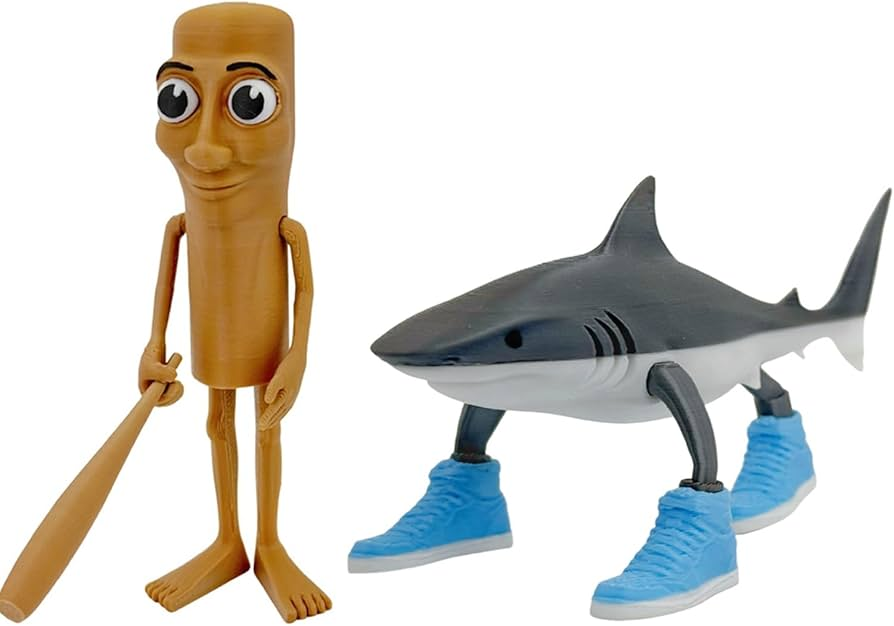

In [6]:
url = "https://m.media-amazon.com/images/I/510i2emhBpL._AC_UF894,1000_QL80_.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

display(img)

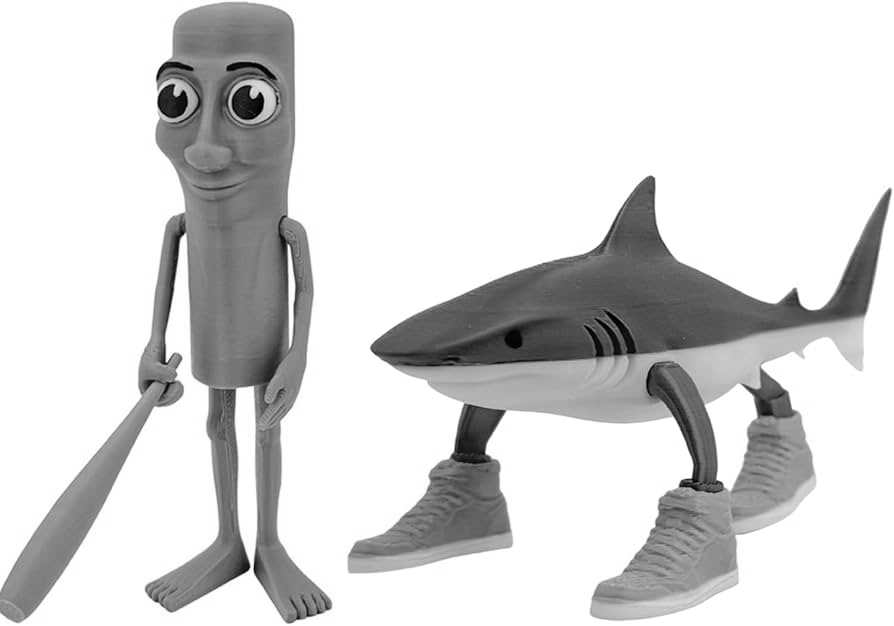

In [7]:
img = img.convert('L') # Convertimos a escala de grises al principio para simplificar

display(img)

In [8]:
img_tensor = T.ToTensor()(img)

print(img_tensor.shape)

torch.Size([1, 626, 894])


In [9]:
# PyTorch Conv2d espera que el tensor tenga la forma: [Batch, Canales, Alto, Ancho]
# Así que añadimos una dimensión extra al principio (el batch de tamaño 1)
img_batch = img_tensor.unsqueeze(0)

print(img_batch.shape)

torch.Size([1, 1, 626, 894])


`unsqueeze(0)` agrega una dimensión en el lugar 0 (batch size en el contexto de Conv2d)

`squeeze()` quita las dimensiones que sean == 1

In [11]:
img_batch.squeeze().shape

torch.Size([626, 894])

In [10]:
print(f"Dimensiones de la imagen original (Píxeles): {img.size}")
print(f"Forma del tensor img_tensor: {img_tensor.shape}")
print(f"Forma del tensor (con batch) img_batch: {img_batch.shape}")

Dimensiones de la imagen original (Píxeles): (894, 626)
Forma del tensor img_tensor: torch.Size([1, 626, 894])
Forma del tensor (con batch) img_batch: torch.Size([1, 1, 626, 894])


In [12]:
# --------- FUNCIÓN PARA FACILITAR LA VISUALIZACIÓN LADO A LADO ---------
def plot_conv_result(original_tensor, conv_result_tensor, title="Resultado de convolución"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Imagen original
    # original_tensor shape: [1, 1, H, W] -> [H, W]
    axes[0].imshow(original_tensor.squeeze(), cmap='gray')
    axes[0].set_title("Imagen Original")
    axes[0].axis('off')

    # Imagen convolucionada
    # conv_result_tensor puede tener valores fuera de [0, 1], usamos min/max automáticos
    axes[1].imshow(conv_result_tensor.squeeze().detach(), cmap='gray')
    axes[1].set_title(title)
    axes[1].axis('off')

    plt.show()

### 2. Nuestro primer filtro: Detectando Bordes

Vamos a definir una convolución explícitamente usando la función de PyTorch `nn.Conv2d` y establecerle manualmente los pesos de un filtro clásico para **detección de bordes verticales** (filtro de Prewitt/Sobel simplificado).

Forma del resultado de convolución: torch.Size([1, 1, 624, 892])


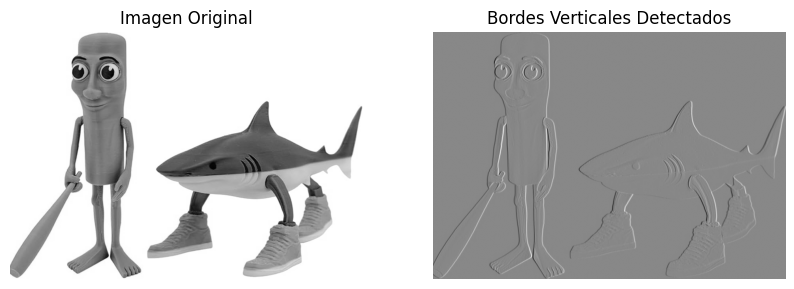

In [13]:
# Filtro para detectar bordes verticales
edge_filter = torch.tensor([
    [-1., 0., 1.],
    [-2., 0., 2.],
    [-1., 0., 1.]
])

# Creamos la capa convolucional
# in_channels=1 (escala de grises), out_channels=1 (un solo filtro a la vez), kernel_size=3 (3x3)
conv_layer = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, bias=False)

# PyTorch requiere que los pesos del filtro tengan la forma: [out_channels, in_channels, H, W]
conv_layer.weight.data = edge_filter.view(1, 1, 3, 3)

# Pasamos la imagen por la capa convolucional
output_edge = conv_layer(img_batch)

print(f"Forma del resultado de convolución: {output_edge.shape}")
plot_conv_result(img_batch, output_edge, "Bordes Verticales Detectados")

### 3. Jueguemos con Filtros Diferentes
En una red neuronal real, estos filtros (sus números o `pesos`) comienzan siendo **aleatorios** y el algoritmo los aprende ("ajusta") durante el entrenamiento para detectar las características que más le importan para la tarea.

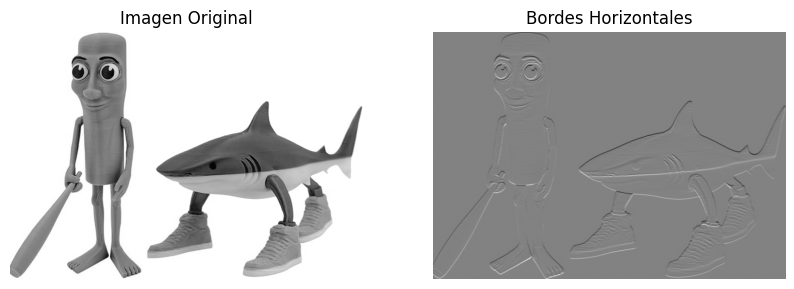

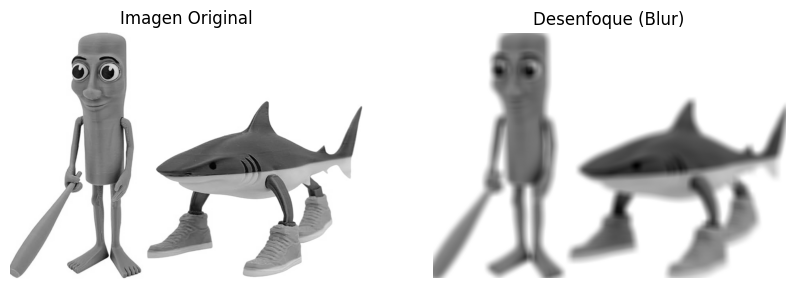

In [17]:
# 1. Filtro de Bordes Horizontales
horizontal_filter = torch.tensor([
    [-1., -2., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  2.,  1.]
])

# 2. Filtro de Desenfoque (Blur) Gaussiano simplificado
blur_filter = torch.ones((20, 20)) / 400.0

def apply_custom_filter(img, custom_filter, title):
    conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=custom_filter.shape, bias=False)
    conv.weight.data = custom_filter.view(1, 1, *custom_filter.shape) # Adaptar dimensiones
    output = conv(img)
    plot_conv_result(img, output, title)

apply_custom_filter(img_batch, horizontal_filter, "Bordes Horizontales")
apply_custom_filter(img_batch, blur_filter, "Desenfoque (Blur)")

### 4. Parámetro: Stride (Zancada)

¿Qué pasa si en lugar de mover el filtro 1 píxel a la vez por la imagen, lo movemos de 2 en 2, o de 4 en 4?
A esto se le llama **Stride**.

Aumentar el *stride* es una forma de "resumir" o reducir la dimensionalidad o resolución de la imagen final que pasa a la siguiente capa.

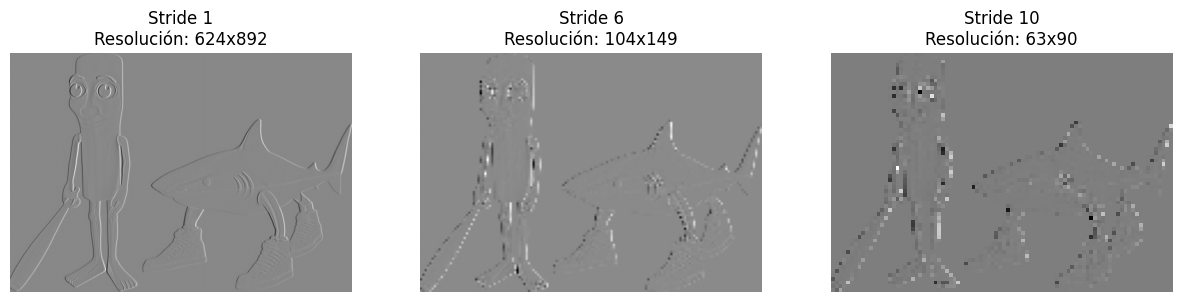

In [20]:
# Probemos con Stride = 6 y Stride = 10 usando el filtro de bordes verticales

conv_stride2 = nn.Conv2d(1, 1, kernel_size=3, stride=6, bias=False)
conv_stride2.weight.data = edge_filter.view(1, 1, 3, 3)
out_stride2 = conv_stride2(img_batch)

conv_stride4 = nn.Conv2d(1, 1, kernel_size=3, stride=10, bias=False)
conv_stride4.weight.data = edge_filter.view(1, 1, 3, 3)
out_stride4 = conv_stride4(img_batch)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(output_edge.squeeze().detach(), cmap='gray')
axes[0].set_title(f"Stride 1\nResolución: {output_edge.shape[2]}x{output_edge.shape[3]}")
axes[0].axis('off')

axes[1].imshow(out_stride2.squeeze().detach(), cmap='gray')
axes[1].set_title(f"Stride 6\nResolución: {out_stride2.shape[2]}x{out_stride2.shape[3]}")
axes[1].axis('off')

axes[2].imshow(out_stride4.squeeze().detach(), cmap='gray')
axes[2].set_title(f"Stride 10\nResolución: {out_stride4.shape[2]}x{out_stride4.shape[3]}")
axes[2].axis('off')
plt.show()

### 5. Parámetro: Padding (Relleno)

Cuando usamos un filtro de 3x3, el centro del filtro nunca puede tocar los píxeles de la orilla de la imagen, ya que el filtro se saldría de los bordes. Por eso, notas que la imagen resultante con stride 1 reduce 2 píxeles de cada lado respecto a la original.

El **Padding** agrega capas de píxeles falsos (normalmente ceros) como marco alrededor de la imagen original para que el centro del filtro pueda procesar mejor los bordes verdaderos de la imagen mantener el tamaño constante después de aplicar la convolución.

In [24]:
# Sin padding (el tamaño se reduce porque el centro de la matriz se detiene antes del borde)
conv_no_pad = nn.Conv2d(1, 1, kernel_size=3, padding=0, bias=False)
conv_no_pad.weight.data = edge_filter.view(1, 1, 3, 3)
out_no_pad = conv_no_pad(img_batch)

# Con padding=1 (mantiene el tamaño de la imagen original con un kernel de 3x3)
conv_pad1 = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
conv_pad1.weight.data = edge_filter.view(1, 1, 3, 3)
out_pad1 = conv_pad1(img_batch)

print(f"Imagen original:    {img_batch.shape}")
print(f"Sin Padding:        {out_no_pad.shape} (¡Se perdieron 2 píxeles por lado!)")
print(f"Con Padding=1:      {out_pad1.shape} (¡Se mantiene el tamaño!)")

Imagen original:    torch.Size([1, 1, 626, 894])
Sin Padding:        torch.Size([1, 1, 624, 892]) (¡Se perdieron 2 píxeles por lado!)
Con Padding=1:      torch.Size([1, 1, 626, 894]) (¡Se mantiene el tamaño!)


---
## ¡Conclusión!

Una red convolucional (CNN) no es más que **muchos canales de estos filtros aplicados uno tras otro**, donde la red *aprende* qué números van adentro del filtro para la tarea en lugar de nosotros tener que predecir cómo diseñar un filtro perfecto.

En lugar de `out_channels=1`, una capa inicial puede tener **32 canales**, ¡buscando 32 patrones distintos a la vez! (bordes verticales, horizontales, esferas de colores, etc...)

### Ejercicio Propuesto:
1. Busca otra URL de una imagen.
2. Juega con **kernel sizes más grandes** (por ejemplo 5x5).
3. Observa qué le pasa a los bordes y a las dimensiones de salida experimentando tú mismo con el `padding`, `stride` y otras transformaciones.

In [ ]:
# ¡Haz tu ejercicio aquí abajo!


